In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# Set pandas options to display the DataFrame without truncation
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.expand_frame_repr', False)  # Disable truncated output

In [2]:
# URL of the dataset
url = "http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data_10_percent.gz"
# url = "http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data.gz"


# 41 Features + 1 label
feature_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
    "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login",
    "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"
]

# Load the dataset into a pandas DataFrame
df = pd.read_csv(url, header=None, names=feature_names)

# Shape of the DataFrame (number of rows, number of columns)
print("Dataframe shape: ", df.shape)
# DataFrame Visualization
print(df.head())

# Extract the labels column into a separate array
labels = df['label'].values

# Remove the labels column from the original DataFrame
df = df.drop(columns=['label'])

# Identify categorical features
categorical_features = ['protocol_type', 'service', 'flag']

# Remove categorical features from the DataFrame
df = df.drop(columns=categorical_features)

# # Identify binary features
# binary_features = [col for col in df.columns if df[col].nunique() == 2]

# # Remove binary features from the DataFrame
# df = df.drop(columns=binary_features)

# Standardize numerical features
scaler = StandardScaler()
X_standardized = scaler.fit_transform(df)

# Create final dataset
X = X_standardized
Y = labels
N = len(X) # |X|
weights_X = np.ones(N) # weights are equally assigned 1

# Unique attack types from the 'label' column
attacks_type = np.unique(labels)
k = len(attacks_type)
print("\n\n", k - 1, "attack types and 1 normal connection")
print(attacks_type)

Dataframe shape:  (494021, 42)
   duration protocol_type service flag  src_bytes  dst_bytes  land  wrong_fragment  urgent  hot  num_failed_logins  logged_in  num_compromised  root_shell  su_attempted  num_root  num_file_creations  num_shells  num_access_files  num_outbound_cmds  is_host_login  is_guest_login  count  srv_count  serror_rate  srv_serror_rate  rerror_rate  srv_rerror_rate  same_srv_rate  diff_srv_rate  srv_diff_host_rate  dst_host_count  dst_host_srv_count  dst_host_same_srv_rate  dst_host_diff_srv_rate  dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  dst_host_serror_rate  dst_host_srv_serror_rate  dst_host_rerror_rate  dst_host_srv_rerror_rate    label
0         0           tcp    http   SF        181       5450     0               0       0    0                  0          1                0           0             0         0                   0           0                 0                  0              0               0      8          8          0.0      

In [3]:
def visulize_labels(labels,title = ""):
    label_counts = pd.Series(labels).value_counts()
    plt.figure(figsize=(12, 6))
    label_counts.plot(kind='bar')
    plt.title(title)
    plt.xlabel('Attack Types')
    plt.ylabel('Frequency')
    for i, v in enumerate(label_counts):
        plt.text(i, v, str(v), ha='center', va='bottom', fontsize=9)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

![hadfkjs](https://drive.google.com/uc?id=1vi9jnfzWIryXbXX0AfKxl38UEauSIUo_)
<!-- something -->

In [4]:
# Algorithm I : D2 - sampling

def weighted_d2_sampling(X, weights_X, k):

    """
    Initialize k-means centroids using weighted D2 sampling.

    Parameters:
    X : np.ndarray, shape (N, n_features)
        The input data.
    weights_X, μₓ(·) : np.ndarray, shape (N,)
        The weights for each data point.
    k : int
        The number of clusters.

    Returns:
    B : np.ndarray, shape (k, n_features)
        The initialized centroids.
    min_distances  : np.ndarray, shape (n_samples,)
        The minimum distances from each point to the nearest centroid.
    closest_centroids : np.ndarray, shape (n_samples,)
        The index of the closest centroid for each point.
    """

    N, n_features = X.shape
    B = np.empty((k, n_features))

    # Step 1: Sample x ∈ X, using μₓ(·) and set B = {x}.
    weights_X_normalized = weights_X/np.sum(weights_X)
    first_idx = np.random.choice(N,p = weights_X_normalized)
    B[0] = X[first_idx]

    min_distances = np.linalg.norm(X - B[0], axis=1)
    closest_centroids = np.zeros(N, dtype=int)

    # Step 2: for i <- 2, 3, . . . , k do
    for i in range(1, k):

        # Step 3: sample x ∈ X with μₓ(x) * d(x,B)² and add to B
        # Compute the weighted probabilities
        updated_weight = weights_X * min_distances**2
        # Normalize the probabilities
        normalized_prob = updated_weight / np.sum(updated_weight)
        # Sample the next centroid using np.random.choice
        sampled_index = np.random.choice(N, p=normalized_prob)
        B[i] = X[sampled_index]

        # Update the minimum distances
        new_distances = np.linalg.norm(X - B[i], axis=1)
        update_mask = new_distances < min_distances
        min_distances[update_mask] = new_distances[update_mask]
        closest_centroids[update_mask] = i

    #Step 4: Return B
    return B, min_distances, closest_centroids

# XX = np.array([[0,0,0],[1,1,1],[2,2,2],[3,3,3],[4,4,4]])
# NN = len(XX)
# kk = 2
# weights_XX = np.ones(NN)
# B,min_distances,closest_centroids = weighted_d2_sampling(XX,weights_XX,kk)
# print(B,min_distances,closest_centroids)
# B, min_distances, closest_centroids = weighted_d2_sampling(X,weights_X,k)

![hadfkjs](https://drive.google.com/uc?id=1_rUjusZxTTFqyG8peuP98tVzNSvDO-Oj)
<!-- something -->

In [5]:
def coresets_construction(X, k, B, min_distances, closest_centroids):

    """
    Construct a coreset for a given set of points and clusters.

    Parameters:
        X                 : ndarray, shape (N, n_features)
                            The input data.
        k                 : int
                            The number of clusters.
        B                 :
                            Set of points representing the cluster centers.
        min_distances     : ndarray, shape (N,)
                            Minimum distances of each point in X to any point in B.
        closest_centroids : ndarray, shape (N,)
                            Indices of the closest centroid for each point in X.
        m                 : int, optional (default=1)
                            The size of the sample to be generated.

    Returns:
        C         : ndarray, shape (m, n_features)
                    The coreset sampled from X.
        weights_C : ndarray, shape (m,)
                    The weights of the coreset points.
    """

    # Get the number of points and features
    N, n_features = X.shape

    # Step 1: α ← 16(log k + 2)
    alpha = 16 * (np.log(k) + 2)

    # Step 4: c_φ ← (1 / |𝒳|) Σ_(x' ∈ 𝒳) d(x', B)
    c_phi = np.sum(min_distances) / N

    # Compute the number of points closest to each centroid
    mod_Bi = np.bincount(closest_centroids, minlength=k)

    # Compute sum of distances for each closest centroid
    sum_distances_Bi = np.zeros(k)
    # Σ_(x' ∈ B_i) d(x', B)
    for i in range(k):
        points_to_centroid = (closest_centroids == i)
        sum_distances_Bi[i] = np.sum(min_distances[points_to_centroid])

    # Step 6: s(x) ← (α d(x, B) / c_φ) + (2α Σ_(x' ∈ B_i) d(x', B) / (|B_i| c_φ)) + (4 |𝒳| / |B_i|)
    term1 = (alpha * min_distances / c_phi) # (α d(x, B) / c_φ)
    term2 = ((2 * alpha * sum_distances_Bi) / (mod_Bi * c_phi))[closest_centroids] # (2α Σ_(x' ∈ B_i) d(x', B))
    term3 = (4 * N / mod_Bi)[closest_centroids] # (4 |𝒳| / |B_i|)
    s_x = term1 + term2 + term3
    # Step 8: p(x) ← s(x) / Σ_(x' ∈ 𝒳) s(x')
    p_x = s_x / np.sum(s_x)

    return p_x

# p_x = coresets_construction(X, k, B, min_distances, closest_centroids)

In [6]:
def sample_m_points(X,Y,p_x,m):
    '''
    Step 9: C ← Sample m weighted points from 𝒳 where each point x has weight 1 / (m * p(x))
    # sampled with probability p(x).
    '''
    C_indices = np.random.choice(len(X), size=m, replace=True, p=p_x)
    # C_indices = np.sort(C_indices)
    C = X[C_indices]
    C_labels = Y[C_indices]
    weights_C =   (1 /( m * p_x[C_indices])) # μc(·) = 1 / (m * p(x))

    return C, weights_C, C_labels, C_indices

![hadfkjs](https://drive.google.com/uc?id=15wabzPHk5ukAPZyUw-yb646F_ZZvYBo9)


In [7]:

def calculate_inertia(X, centroids, weights=None):
    # Find the closest centroids for each point
    closest_centroids, min_distances = pairwise_distances_argmin_min(X, centroids)

    # If weights are not provided, set them to 1 for all points
    if weights is None:
        weights = np.ones(len(X))

    # Calculate the weighted inertia
    weighted_inertia = np.sum(weights * (min_distances ** 2))

    return weighted_inertia

![hadfkjs](https://drive.google.com/uc?id=1asdXoKcqZkW5sYck--ksfeDbrFYi0E84)
### Definitions:

- **cost(X, Q)**: Clustering cost on dataset \( X \) when the query/centroid is \( Q \).

### Notations:

- **X**: Full dataset
- **C**: Coreset of \( X \)

### Clustering Costs:

- **cost\_XQx**: Clustering cost on \( X \) when the centroid is \( Q_x \) (optimal for \( X \)).
- **cost\_CQx**: Clustering cost on \( C \) when the centroid is \( Q_x \) (optimal for \( X \)).

- **cost\_XQc**: Clustering cost on \( X \) when the centroid is \( Q_c \) (optimal for \( C \)).
- **cost\_CQc**: Clustering cost on \( C \) when the centroid is \( Q_c \) (optimal for \( C \)).

**Note**: \( Q_x \) and \( Q_c \) are derived by k-means on \( X \) and \( C \) respectively. Therefore, they might not be the most optimal centroids.





In [8]:
# Apply K-Means clustering on full data set X
kmeans_X = KMeans(n_clusters=k, init = "random", random_state=11,n_init=5,max_iter=1)
kmeans_X.fit(X,sample_weight= weights_X)

Qx_initseed = kmeans_X.cluster_centers_

In [9]:
# Apply K-Means clustering on full data set X
kmeans_X = KMeans(n_clusters=k, init = "k-means++", random_state=53,n_init="auto")
kmeans_X.fit(X,sample_weight= weights_X)

# Optimal centroid for X for Cost(X,Q)
Qx = kmeans_X.cluster_centers_
cost_XQx = calculate_inertia(X,Qx,weights_X)

# Unique attack types from the 'label' column
clustered_labels_X =  kmeans_X.labels_

In [10]:
def Coreset_KMeans_Cost(C, weights_C, init_Q): # Pass Qx as a parameter
    # Apply K-Means clustering on Coreset C
    kmeans_C = KMeans(n_clusters=k, init = init_Q, random_state=67,n_init=1) # Use the passed Qx
    kmeans_C.fit(C,sample_weight =  weights_C)
    # clustering cost (inertia) on full data set X when K Means runs only on Coresets
    cost_XQc = calculate_inertia(X,kmeans_C.cluster_centers_,weights_X)
    cost_CQc = kmeans_C.inertia_
    return cost_CQc, cost_XQc

In [11]:
# |X| = N = 4,94,021
B, min_distances, closest_centroids = weighted_d2_sampling(X,weights_X,k)
p_x = coresets_construction(X, k, B, min_distances, closest_centroids)
C, weights_C, C_labels, C_indices = sample_m_points(X,Y,p_x,m = 10000)

cost_CQc,cost_XQc = Coreset_KMeans_Cost(C, weights_C,Qx)
cost_CQx = calculate_inertia(C,Qx,weights_C)

print("sum of weights of X : ",np.sum(weights_X)) # N
print("sum of weights of C : ",np.sum(weights_C)) # m
print("cost(X,Q*c) : ",cost_XQc)
print("cost(C,Q*c) : ",cost_CQc)
print("cost(X,Q*x) : ",cost_XQx)
print("cost(C,Q*x) : ",cost_CQx)

sum of weights of X :  494021.0
sum of weights of C :  489069.5046560087
cost(X,Q*c) :  2209250.255535879
cost(C,Q*c) :  2153293.030875129
cost(X,Q*x) :  2203843.0870299623
cost(C,Q*x) :  2160770.6739207683


In [12]:
def benchmark_coresets(Coreset_size,X,weights_X,k,iterations = 1):
    cost_XQc_all = []
    cost_CQc_all = []
    weights_sum_all = []
    for iter in range(1,iterations + 1):
        B, min_distances, closest_centroids = weighted_d2_sampling(X,weights_X,k)
        p_x = coresets_construction(X, k, B, min_distances, closest_centroids)
        cost_XQc_iter = []
        cost_CQc_iter = []
        weights_sum_iter = []
        for m in Coreset_size:
            C, weights_C, C_labels, C_indices = sample_m_points(X,Y,p_x,m)
            cost_CQc,cost_XQc = Coreset_KMeans_Cost(C, weights_C,Qx)
            # cost_CQx = calculate_inertia(C,Qx,weights_C)
            # if(cost_CQc > cost_CQx):
            #     cost_CQc = cost_CQx
            #     cost_XQc = cost_XQx

            cost_XQc_iter.append(cost_XQc)
            cost_CQc_iter.append(cost_CQc)
            weights_sum_iter.append(np.sum(weights_C))

        cost_XQc_all.append(cost_XQc_iter)
        cost_CQc_all.append(cost_CQc_iter)
        weights_sum_all.append(weights_sum_iter)
    return np.array(cost_XQc_all),np.array(cost_CQc_all),np.array(weights_sum_all)

In [13]:
# print(N,2 * N / 100)
Coreset_sizes = [i for i in range(100,5000,50)] + [i for i in range(5000,20000,200)] + [i for i in range(20000,100001,2500)]
Coreset_sizes = np.array(Coreset_sizes)
print(Coreset_sizes.shape)
print(Coreset_sizes)

(206,)
[   100    150    200    250    300    350    400    450    500    550
    600    650    700    750    800    850    900    950   1000   1050
   1100   1150   1200   1250   1300   1350   1400   1450   1500   1550
   1600   1650   1700   1750   1800   1850   1900   1950   2000   2050
   2100   2150   2200   2250   2300   2350   2400   2450   2500   2550
   2600   2650   2700   2750   2800   2850   2900   2950   3000   3050
   3100   3150   3200   3250   3300   3350   3400   3450   3500   3550
   3600   3650   3700   3750   3800   3850   3900   3950   4000   4050
   4100   4150   4200   4250   4300   4350   4400   4450   4500   4550
   4600   4650   4700   4750   4800   4850   4900   4950   5000   5200
   5400   5600   5800   6000   6200   6400   6600   6800   7000   7200
   7400   7600   7800   8000   8200   8400   8600   8800   9000   9200
   9400   9600   9800  10000  10200  10400  10600  10800  11000  11200
  11400  11600  11800  12000  12200  12400  12600  12800  13000  13200

In [14]:
cost_XQc,cost_CQc,weights_sum = benchmark_coresets(Coreset_sizes,X,weights_X,k,iterations = 15)

In [50]:
print("N :", N)
s1 = 0
s2 = 170 #slicing
Coreset_size = Coreset_sizes[s1:s2]
cost_XQc_mean = cost_XQc.mean(axis = 0)[s1:s2]
cost_CQc_mean = cost_CQc.mean(axis = 0)[s1:s2]
weights_sum_mean = weights_sum.mean(axis = 0)[s1:s2]
cost_XQc_median = np.median(cost_XQc,axis = 0)[s1:s2]
cost_CQc_median = np.median(cost_CQc,axis = 0)[s1:s2]
weights_sum_median = np.median(weights_sum,axis = 0)[s1:s2]

N : 494021


Text(0, 0.5, 'Change in cost(X,Q*c) and cost(X,Q*x)')

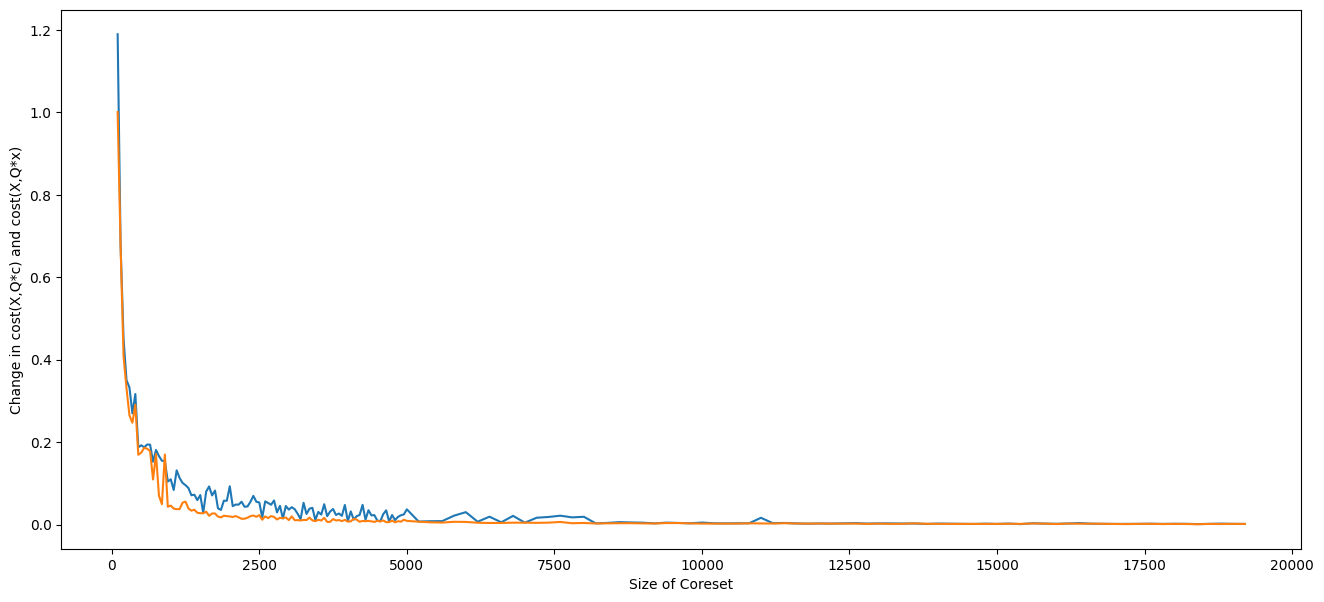

In [51]:
cost_diff_mean = abs(cost_XQc_mean - cost_XQx)/cost_XQx
cost_diff_median = abs(cost_XQc_median - cost_XQx)/cost_XQx
plt.figure(figsize=(16, 7))
plt.plot(Coreset_size,cost_diff_mean)
plt.plot(Coreset_size,cost_diff_median)
plt.xlabel('Size of Coreset')
plt.ylabel('Change in cost(X,Q*c) and cost(X,Q*x)')

Text(0, 0.5, 'Change in Epsilon')

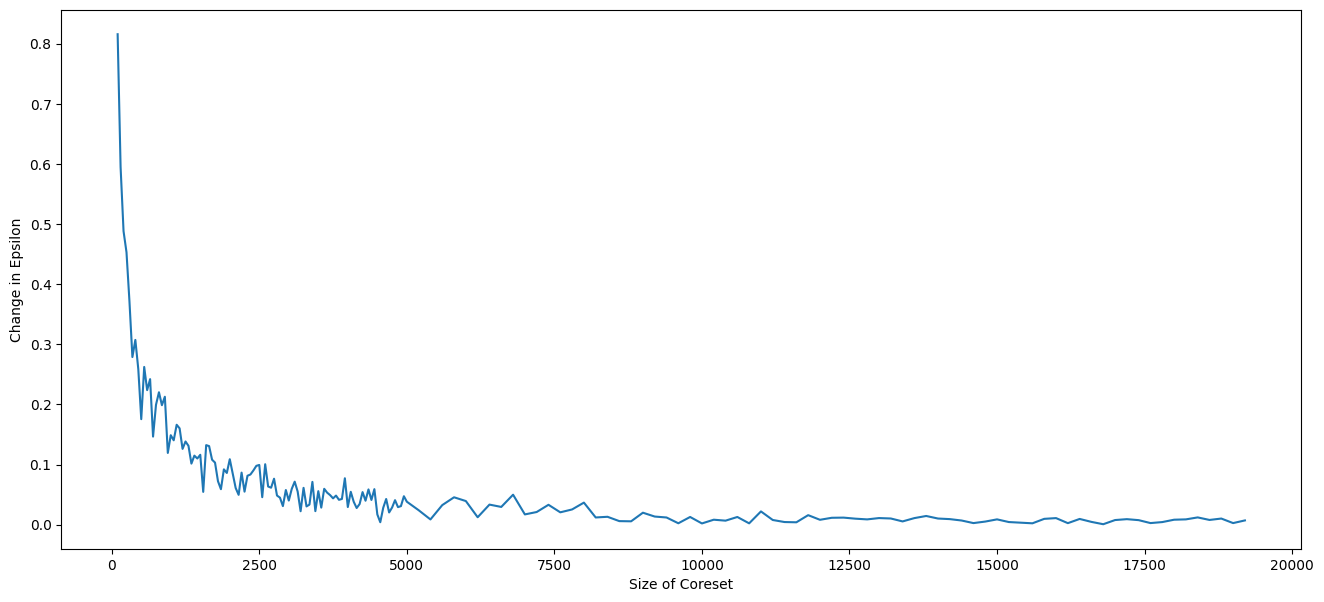

In [52]:
epsilon_mean = abs(cost_XQc_mean - cost_CQc_mean)/cost_XQc_mean
epsilon_median = abs(cost_XQc_median - cost_CQc_median)/cost_XQc_median
plt.figure(figsize=(16, 7))
plt.plot(Coreset_size,epsilon_mean)
# plt.plot(Coreset_size,epsilon_median)
plt.xlabel('Size of Coreset')
plt.ylabel('Change in Epsilon')

Text(0, 0.5, 'Change in weights sum')

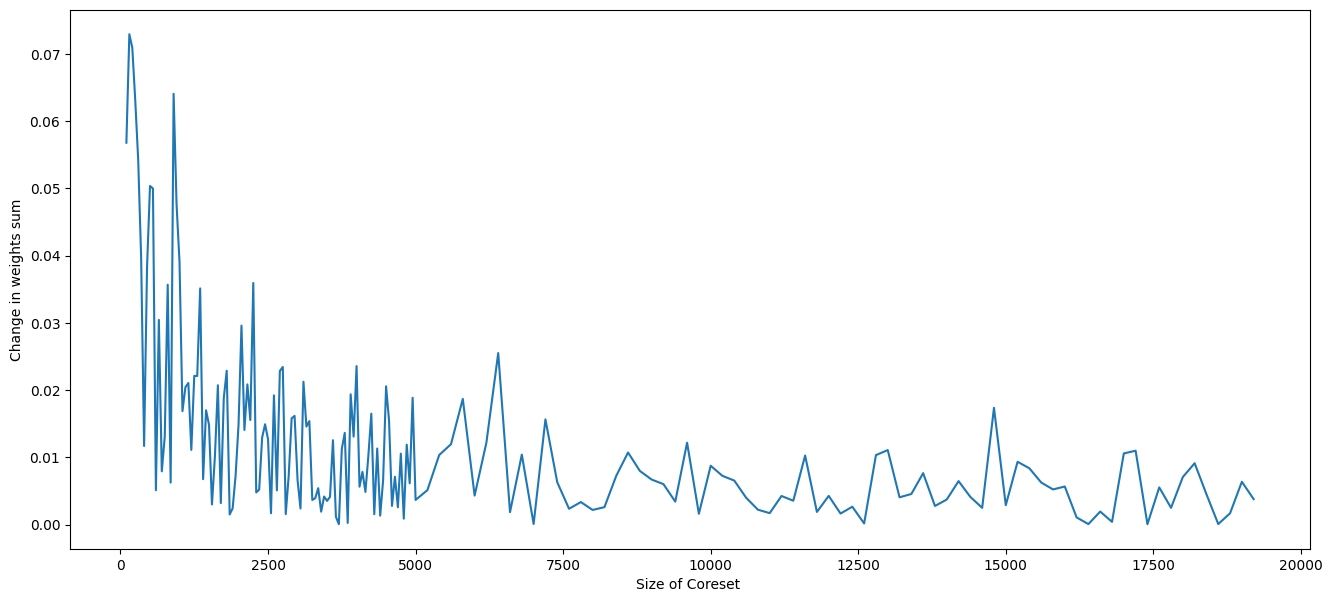

In [53]:
weights_diff_mean = abs(weights_sum_mean - np.sum(weights_X))/np.sum(weights_X)
weights_diff_median = abs(weights_sum_median - np.sum(weights_X))/np.sum(weights_X)
plt.figure(figsize=(16, 7))
plt.plot(Coreset_size,weights_diff_mean)
# plt.plot(Coreset_size,weights_diff_median)
plt.xlabel('Size of Coreset ')
plt.ylabel('Change in weights sum')